# Evaluation

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from ultralytics import YOLO
%matplotlib inline

WEIGHTS_PATH = "../../runs/runs/prototype/full_finetune/weights/best.pt"
DATA_CONFIG = "../data/smoke.yaml"

assert Path(WEIGHTS_PATH).exists(), f"Poids introuvables : {WEIGHTS_PATH} — entraîne d'abord un modèle."
model = YOLO(WEIGHTS_PATH)

## 1.Evaluation rapide

In [2]:
metrics = model.val(data=DATA_CONFIG, split="val", plots=True, verbose=False)

print(f"mAP50     : {metrics.box.map50:.4f}")
print(f"mAP50-95  : {metrics.box.map:.4f}")
print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")

Ultralytics 8.4.129  Python-3.11.6 torch-2.13.0+cpu CPU (AMD Ryzen 7 5800X 8-Core Processor)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 821.9472.6 MB/s, size: 181.2 KB)
val: Scanning Z:\Personal project\Computer Vison\smoke_detection\data\labels\val.cache... 2152 images, 1004 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2152/2152  0.0s
val: Z:\Personal project\Computer Vison\smoke_detection\data\images\val\WEB07534.jpg: corrupt JPEG restored and saved
val: Z:\Personal project\Computer Vison\smoke_detection\data\images\val\WEB11243.jpg: corrupt JPEG restored and saved
val: Z:\Personal project\Computer Vison\smoke_detection\data\images\val\WEB11244.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 135/135 3.8it/s 35.7s0.3s
                   all       2152       2618      0.661      0.565      0.634      0.335
Spe

## 2.detaille sur class

In [3]:
rows = []
for i, cls_idx in enumerate(metrics.ap_class_index):
    p, r = metrics.box.p[i], metrics.box.r[i]
    f1 = 2 * p * r / (p + r + 1e-9)
    rows.append({
        "classe": metrics.names[int(cls_idx)],
        "precision": round(float(p), 3),
        "recall": round(float(r), 3),
        "f1": round(float(f1), 3),
        "mAP50": round(float(metrics.box.ap50[i]), 3),
    })
per_class_df = pd.DataFrame(rows)
per_class_df


,classe,precision,recall,f1,mAP50
0,smoke,0.706,0.623,0.662,0.698
1,fire,0.616,0.508,0.556,0.571


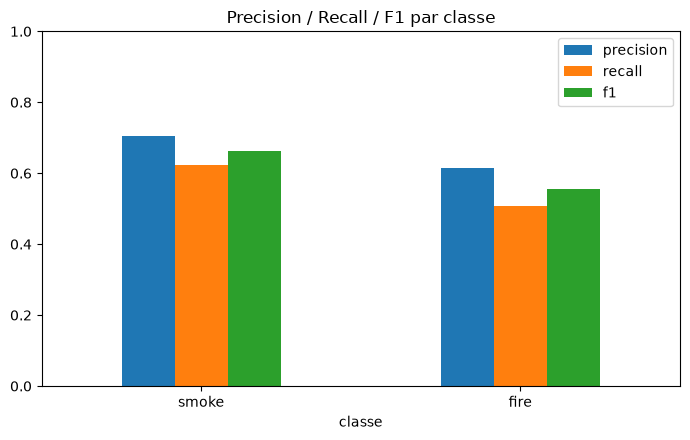

In [6]:
per_class_df.set_index("classe")[["precision", "recall", "f1"]].plot(
    kind="bar", figsize=(7, 4.5), rot=0
)
plt.title("Precision / Recall / F1 par classe")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 3. Sensibilité au seuil de confiance (arbitrage precision/recall)

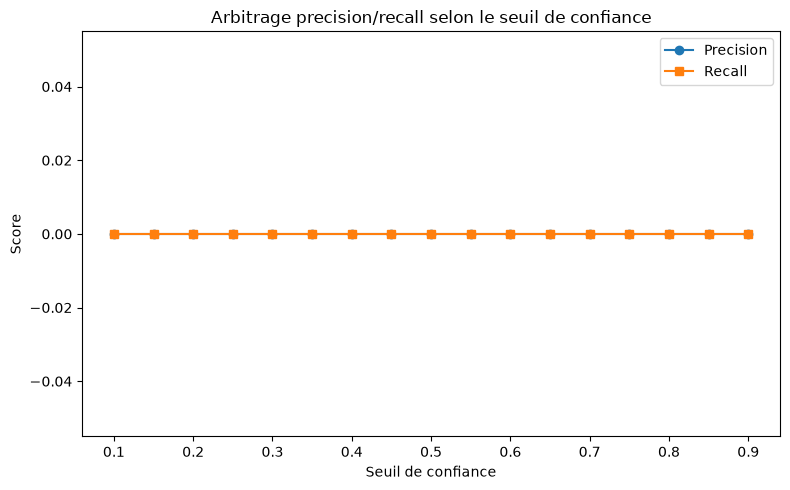

In [7]:
val_images_dir = Path("../data/images/val")
val_labels_dir = Path("../data/labels/val")
val_images = sorted([p for p in val_images_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])[:100]

def load_gt_boxes(image_path):
    label_path = val_labels_dir / f"{image_path.stem}.txt"
    if not label_path.exists():
        return []
    boxes = []
    for line in open(label_path):
        parts = line.split()
        if len(parts) == 5:
            boxes.append(int(parts[0]))
    return boxes

conf_thresholds = np.arange(0.1, 0.95, 0.05)
sweep_rows = []

for conf in conf_thresholds:
    tp, fp, fn = 0, 0, 0
    for img_path in val_images:
        gt_classes = load_gt_boxes(img_path)
        result = model.predict(str(img_path), conf=conf, verbose=False)[0]
        pred_classes = [int(b.cls) for b in result.boxes] if result.boxes is not None else []

        # Comparaison simplifiée au niveau image (comptage par classe, pas de matching IoU) :
        # suffisant pour visualiser la tendance precision/recall, pas pour un score officiel
        # (le score officiel provient de model.val() ci-dessus).
        matched = min(len(gt_classes), len(pred_classes))
        tp += matched
        fp += max(0, len(pred_classes) - matched)
        fn += max(0, len(gt_classes) - matched)

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    sweep_rows.append({"conf_threshold": conf, "precision": precision, "recall": recall})

sweep_df = pd.DataFrame(sweep_rows)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_df["conf_threshold"], sweep_df["precision"], label="Precision", marker="o")
ax.plot(sweep_df["conf_threshold"], sweep_df["recall"], label="Recall", marker="s")
ax.set_xlabel("Seuil de confiance")
ax.set_ylabel("Score")
ax.set_title("Arbitrage precision/recall selon le seuil de confiance")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Inspection visuelle des faux négatifs (fumées ratées)

In [8]:
def has_prediction_for_class(result, class_id):
    if result.boxes is None:
        return False
    return class_id in [int(b.cls) for b in result.boxes]

false_negatives = []
for img_path in val_images:
    gt_classes = set(load_gt_boxes(img_path))
    if not gt_classes:
        continue
    result = model.predict(str(img_path), conf=0.35, verbose=False)[0]
    for cls_id in gt_classes:
        if not has_prediction_for_class(result, cls_id):
            false_negatives.append((img_path, cls_id))
            break

print(f"{len(false_negatives)} image(s) avec au moins un faux négatif (sur {len(val_images)} testées)")

n_show = min(6, len(false_negatives))
if n_show:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for (img_path, cls_id), ax in zip(false_negatives[:n_show], axes.flatten()):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"Classe manquée : {model.names[cls_id]}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


0 image(s) avec au moins un faux négatif (sur 100 testées)


**Pourquoi c'est utile** : regarder concrètement les images ratées révèle souvent
un pattern (fumée trop diffuse, contre-jour, très petite dans l'image...) — c'est le
point de départ le plus efficace pour prioriser l'enrichissement du dataset
(voir README, section optimisation, point 3 "active learning").

## 5. Comparaison de plusieurs checkpoints/variantes

In [10]:
# Utile si plusieurs runs ont été faits (ex: notebook 03 : full_finetune vs frozen_backbone)
checkpoints = {
    "full_finetune": "../../runs/runs/prototype/full_finetune/weights/best.pt",
    "frozen_backbone": "../../runs/runs/prototype/frozen_backbone/weights/best.pt",
}

comparison_rows = []
for name, path in checkpoints.items():
    if not Path(path).exists():
        continue
    m = YOLO(path)
    val_metrics = m.val(data=DATA_CONFIG, split="val", verbose=False, plots=False)
    comparison_rows.append({
        "run": name,
        "mAP50": round(float(val_metrics.box.map50), 4),
        "mAP50-95": round(float(val_metrics.box.map), 4),
        "precision": round(float(val_metrics.box.mp), 4),
        "recall": round(float(val_metrics.box.mr), 4),
    })

pd.DataFrame(comparison_rows)


Ultralytics 8.4.129  Python-3.11.6 torch-2.13.0+cpu CPU (AMD Ryzen 7 5800X 8-Core Processor)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 735.4403.9 MB/s, size: 176.3 KB)
val: Scanning Z:\Personal project\Computer Vison\smoke_detection\data\labels\val.cache... 2152 images, 1004 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2152/2152  0.0s
val: Z:\Personal project\Computer Vison\smoke_detection\data\images\val\WEB07534.jpg: corrupt JPEG restored and saved
val: Z:\Personal project\Computer Vison\smoke_detection\data\images\val\WEB11243.jpg: corrupt JPEG restored and saved
val: Z:\Personal project\Computer Vison\smoke_detection\data\images\val\WEB11244.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 135/135 3.7it/s 36.4s0.3s
                   all       2152       2618      0.661      0.565      0.634      0.335
Spe

,run,mAP50,mAP50-95,precision,recall
0,full_finetune,0.6344,0.3353,0.6606,0.5655
1,frozen_backbone,0.5854,0.3065,0.6398,0.5271
